# PneumoFusionNet — MIMIC-CXR Image Baseline
## Binary Pneumonia Detection using ResNet50 + GCSA Attention + Depthwise Separable Convolution

### Project Overview
This notebook adapts PneumoFusionNet for the MIMIC-CXR JPG dataset (P10 subset).
Phase 1 focuses on image-only binary classification.

The model combines:
- ResNet50 backbone (pretrained, 1-channel grayscale)
- Global Context Spatial Attention (GCSA)
- Depthwise Separable Convolution (DSC)


In [1]:
import os, random, copy, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score, auc
)
from collections import Counter

# Set seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA Memory:', torch.cuda.get_device_properties(DEVICE).total_memory / 1e9, 'GB')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA Memory: 4.294508544 GB


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR   = r'C:\2026\PneumoFusionNet\mimic\mimic_pilot_139'
CSV_PATH   = os.path.join(BASE_DIR, 'dataset_139', 'mimic_dataset.csv')
SAVE_DIR   = os.path.join(BASE_DIR, 'outputs')
MODEL_PATH = os.path.join(SAVE_DIR, 'best_pneumofusion_mimic.pth')

IMG_SIZE      = 224
BATCH_SIZE    = 8
NUM_EPOCHS    = 40
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
NUM_CLASSES   = 2
WARMUP_EPOCHS = 3
GRAD_CLIP     = 1.0

CLASSES = ['NORMAL', 'PNEUMONIA']

os.makedirs(SAVE_DIR, exist_ok=True)
print('CSV path :', CSV_PATH)
print('Exists   :', os.path.exists(CSV_PATH))
print('Save dir :', SAVE_DIR)

CSV path : C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\dataset_139\mimic_dataset.csv
Exists   : True
Save dir : C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\outputs


## Step 1: Dataset Loading & Class Distribution Check

In [3]:
df = pd.read_csv(CSV_PATH)

# ── Update image paths to current location in workspace ────────────────────────

OLD_IMG = r'C:\2026\project\mimic\MIMIC_CXR_JPG_P1\p10'
NEW_IMG = r'C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\mimic-cxr-jpg\2.1.0\files\p10'
df['image_path'] = df['image_path'].str.replace(OLD_IMG, NEW_IMG, regex=False)

# Verify images
missing = df['image_path'].apply(lambda p: not os.path.exists(p)).sum()
print('Total samples :', df.shape[0])
print('Images found  :', len(df) - missing, '/', len(df))
if missing > 0:
    print('WARNING: Missing', missing, 'images — check paths!')
    print('Sample missing:', df[df['image_path'].apply(lambda p: not os.path.exists(p))]['image_path'].iloc[0])
else:
    print('All images found!')

print('\nClass distribution:')
class_dist = df['label_name'].value_counts()
print(class_dist)
print(f'\nRatio (NORMAL : PNEUMONIA) = {class_dist["Normal"] / class_dist["Pneumonia"]:.2f} : 1')
print('\nFirst 5 rows:')
print(df.head())

Total samples : 139
Images found  : 139 / 139
All images found!

Class distribution:
Normal       118
Pneumonia     21
Name: label_name, dtype: int64

Ratio (NORMAL : PNEUMONIA) = 5.62 : 1

First 5 rows:
   subject_id  study_id                                         image_path  \
0    10000032  50414267  C:\2026\PneumoFusionNet\mimic\1000_dataset\res...   
1    10000032  53189527  C:\2026\PneumoFusionNet\mimic\1000_dataset\res...   
2    10000032  53911762  C:\2026\PneumoFusionNet\mimic\1000_dataset\res...   
3    10000032  56699142  C:\2026\PneumoFusionNet\mimic\1000_dataset\res...   
4    10000898  50771383  C:\2026\PneumoFusionNet\mimic\1000_dataset\res...   

   label label_name  
0      0     Normal  
1      0     Normal  
2      0     Normal  
3      0     Normal  
4      0     Normal  


## Step 2: Visualise Sample Images

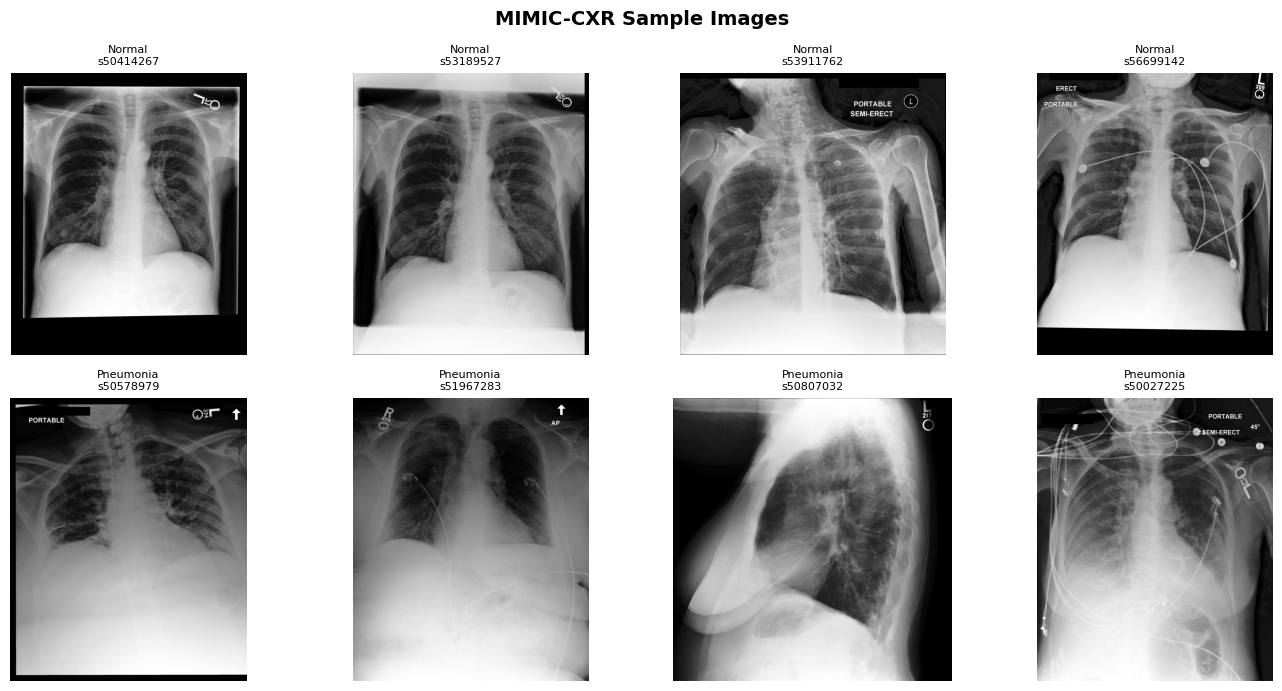

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('MIMIC-CXR Sample Images', fontsize=14, fontweight='bold')
for row, lname in enumerate(['Normal', 'Pneumonia']):
    subset = df[df.label_name == lname].head(4)
    for col, (_, rec) in enumerate(subset.iterrows()):
        ax = axes[row][col]
        try:
            img = Image.open(rec.image_path).convert('L')
            ax.imshow(img, cmap='gray')
        except Exception as e:
            ax.text(0.5, 0.5, str(e)[:30], ha='center', transform=ax.transAxes, fontsize=7)
        ax.set_title(f'{lname}\ns{rec.study_id}', fontsize=8)
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sample_images.png'), dpi=120, bbox_inches='tight')
plt.show()

## Step 3: Train / Val / Test Split (70 / 15 / 15) — Stratified

In [5]:
# First split: 70% train, 30% temp (val+test)
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)

# Second split: split temp 50/50 -> val and test
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print('=' * 60)
print('DATASET SPLIT SUMMARY')
print('=' * 60)
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n_total    = len(split_df)
    n_pneumonia = split_df['label'].sum()
    n_normal   = (split_df['label'] == 0).sum()
    ratio = n_normal / n_pneumonia if n_pneumonia > 0 else float('inf')
    print(f'{split_name:6s} | Total: {n_total:3d} | Normal: {n_normal:3d} | Pneumonia: {n_pneumonia:3d} | Ratio: {ratio:.2f}:1')
print('=' * 60)

DATASET SPLIT SUMMARY
Train  | Total:  97 | Normal:  82 | Pneumonia:  15 | Ratio: 5.47:1
Val    | Total:  21 | Normal:  18 | Pneumonia:   3 | Ratio: 6.00:1
Test   | Total:  21 | Normal:  18 | Pneumonia:   3 | Ratio: 6.00:1


## Step 4: Compute Dataset-Specific Normalization Stats

In [6]:
# Compute mean and std from training set only (avoid data leakage)
print('Computing normalization stats from training set...')
means = []
stds  = []

for idx in range(min(len(train_df), 200)):  # Sample first 200
    try:
        img = Image.open(train_df.iloc[idx]['image_path']).convert('L')
        img_array = np.array(img, dtype=np.float32) / 255.0
        means.append(img_array.mean())
        stds.append(img_array.std())
    except:
        continue

MEAN = [np.mean(means)]
STD  = [np.mean(stds)]
print(f'Computed MEAN: {MEAN[0]:.4f}')
print(f'Computed STD : {STD[0]:.4f}')
print('\n(These replace the ImageNet stats for grayscale chest X-rays)')

Computing normalization stats from training set...
Computed MEAN: 0.4664
Computed STD : 0.3033

(These replace the ImageNet stats for grayscale chest X-rays)


## Step 5: Transforms — Grayscale (1 Channel)

In [7]:
tfms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256, 256)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'test': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
}
print('Transforms ready (dataset-specific normalization stats).')

Transforms ready (dataset-specific normalization stats).


## Step 6: Dataset Class & WeightedRandomSampler for Train Set

In [8]:
class MIMICDataset(Dataset):
    """Load images from MIMIC-CXR with optional transforms."""
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row.image_path)
        if self.transform:
            img = self.transform(img)
        label = int(row.label)
        return img, label


# Weighted sampler for training only (handles class imbalance)
train_labels  = train_df['label'].values
class_counts  = np.bincount(train_labels)
print(f'Class counts in train set: {dict(zip(CLASSES, class_counts))}')

sample_weights = [1.0 / class_counts[l] for l in train_labels]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Create dataloaders
dataloaders = {
    'train': DataLoader(
        MIMICDataset(train_df, tfms['train']),
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=0
    ),
    'val': DataLoader(
        MIMICDataset(val_df, tfms['val']),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    ),
    'test': DataLoader(
        MIMICDataset(test_df, tfms['test']),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    ),
}

dataset_sizes = {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}
print(f'Dataset sizes: {dataset_sizes}')

# Verify batch shape
sample_batch, sample_labels = next(iter(dataloaders['train']))
print(f'Batch shape (B,C,H,W): {sample_batch.shape}')
print(f'Labels in batch      : {sample_labels}')

Class counts in train set: {'NORMAL': 82, 'PNEUMONIA': 15}
Dataset sizes: {'train': 97, 'val': 21, 'test': 21}
Batch shape (B,C,H,W): torch.Size([8, 1, 224, 224])
Labels in batch      : tensor([0, 1, 0, 1, 1, 1, 0, 1])


## Step 7: Verify Sampler is Actually Balancing

In [9]:
print('Verifying WeightedRandomSampler is balancing batches...')
batch_labels = []
for _, lbls in dataloaders['train']:
    batch_labels.extend(lbls.tolist())
    if len(batch_labels) >= 500:
        break

sampled_counts  = Counter(batch_labels)
print(f'Original train class counts      : {dict(zip(CLASSES, class_counts))}')
print(f'Sampled distribution (500 samples): {dict(sampled_counts)}')
sampled_ratio  = sampled_counts[1] / sampled_counts[0] if sampled_counts[0] > 0 else 0
original_ratio = class_counts[1] / class_counts[0] if class_counts[0] > 0 else 0
print(f'Original imbalance ratio: {original_ratio:.3f}')
print(f'Sampled imbalance ratio : {sampled_ratio:.3f}')
if sampled_ratio > original_ratio * 0.8:
    print('Sampler is working correctly!')
else:
    print('WARNING: Sampler may not be balancing properly')

Verifying WeightedRandomSampler is balancing batches...
Original train class counts      : {'NORMAL': 82, 'PNEUMONIA': 15}
Sampled distribution (500 samples): {0: 49, 1: 48}
Original imbalance ratio: 0.183
Sampled imbalance ratio : 0.980
Sampler is working correctly!


## Step 8: Model Architecture — PneumoFusionNet

In [10]:
class GCSA(nn.Module):
    """Global Channel-Spatial Attention
    - Channel attention: avg + max pool -> MLP -> sigmoid
    - Spatial attention: channel-wise mean + max -> Conv -> sigmoid
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels)
        )
        self.sigmoid      = nn.Sigmoid()
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        B, C, H, W = x.shape
        avg    = self.avg_pool(x).view(B, C)
        mx     = self.max_pool(x).view(B, C)
        ch_att = self.sigmoid(self.mlp(avg) + self.mlp(mx)).view(B, C, 1, 1)
        x      = x * ch_att
        sp     = torch.cat([x.mean(1, keepdim=True), x.max(1, keepdim=True)[0]], dim=1)
        sp_att = self.sigmoid(self.conv_spatial(sp))
        return x * sp_att


class DSC(nn.Module):
    """Depthwise Separable Convolution"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, padding=1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        return F.relu(self.bn(self.pw(self.dw(x))), inplace=True)


class PneumoFusionNet(nn.Module):
    """ResNet50 + DSC + GCSA for pneumonia detection"""
    def __init__(self, num_classes=NUM_CLASSES, freeze_until=7):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Adapt conv1: 3-channel -> 1-channel (grayscale)
        original_conv1 = resnet.conv1
        resnet.conv1   = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)

        # Initialize from RGB pretrained weights (average across channels)
        with torch.no_grad():
            resnet.conv1.weight = nn.Parameter(
                original_conv1.weight.mean(dim=1, keepdim=True)
            )

        # Backbone: everything except FC
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # Freeze early layers
        for i, child in enumerate(self.backbone.children()):
            if i < freeze_until:
                for p in child.parameters():
                    p.requires_grad = False

        # Attention + classification head
        self.dsc        = DSC(2048, 1024)
        self.gcsa       = GCSA(1024)
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)          # [B, 2048, 7, 7]
        x = self.dsc(x)               # [B, 1024, 7, 7]
        x = self.gcsa(x)              # [B, 1024, 7, 7]
        x = self.pool(x).flatten(1)   # [B, 1024]
        return self.classifier(x)      # [B, 2]

    def get_features(self, x):
        """Extract 1024-d embeddings for Phase 2 multimodal fusion."""
        x = self.backbone(x)
        x = self.dsc(x)
        x = self.gcsa(x)
        return self.pool(x).flatten(1)  # [B, 1024]


# Instantiate model
model = PneumoFusionNet().to(DEVICE)

# Sanity checks
dummy = torch.randn(4, 1, 224, 224).to(DEVICE)
print('Output shape  :', model(dummy).shape)               # [4, 2]
print('Feature shape :', model.get_features(dummy).shape)  # [4, 1024]

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,} ({trainable/total*100:.1f}%)')

Output shape  : torch.Size([4, 2])
Feature shape : torch.Size([4, 1024])
Total params    : 26,277,477
Trainable params: 17,740,453 (67.5%)


## Step 9: Loss, Optimizer & Scheduler with LR Warmup

In [11]:
# Loss: CrossEntropyLoss (no weights — class imbalance handled by WeightedRandomSampler)
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler: Linear warmup for WARMUP_EPOCHS, then cosine annealing
linear_warmup = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine_anneal = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS)
scheduler     = SequentialLR(
    optimizer,
    schedulers=[linear_warmup, cosine_anneal],
    milestones=[WARMUP_EPOCHS]
)

print('Loss function : CrossEntropyLoss (no weights)')
print('Optimizer     : AdamW')
print(f'Learning rate : {LR}')
print(f'Weight decay  : {WEIGHT_DECAY}')
print(f'Warmup epochs : {WARMUP_EPOCHS}')
print(f'Total epochs  : {NUM_EPOCHS}')
print(f'Gradient clip : {GRAD_CLIP}')

Loss function : CrossEntropyLoss (no weights)
Optimizer     : AdamW
Learning rate : 0.0001
Weight decay  : 0.0001
Warmup epochs : 3
Total epochs  : 40
Gradient clip : 1.0


## Step 10: Training Loop with Validation Monitoring

In [12]:
def evaluate(model, dataloader, criterion, device):
    """Evaluate model on a dataloader."""
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            total_loss  += loss.item() * len(labels)
            probs        = F.softmax(outputs, dim=1)[:, 1]
            all_preds.extend(outputs.argmax(1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    auc_score = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0

    return avg_loss, accuracy, auc_score, all_preds, all_labels, all_probs


# Training loop
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}

best_val_auc     = 0.0
best_epoch       = 0
patience         = 10
patience_counter = 0

print('\n' + '='*80)
print('TRAINING STARTED')
print('='*80)

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss    = 0.0
    train_correct = 0
    train_n       = 0

    for imgs, labels in dataloaders['train']:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        train_loss    += loss.item() * len(labels)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_n       += len(labels)

    scheduler.step()

    train_loss_avg = train_loss / train_n
    train_acc      = train_correct / train_n

    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model, dataloaders['val'], criterion, DEVICE
    )

    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc     = val_auc
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        best_marker = ' <- BEST'
    else:
        best_marker = ''
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | '
              f'Train Loss: {train_loss_avg:.4f} ({train_acc:.3f}) | '
              f'Val Loss: {val_loss:.4f} ({val_acc:.3f}) | '
              f'Val AUC: {val_auc:.4f}{best_marker}')

    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
        break

print('='*80)
print(f'Training complete. Best val AUC: {best_val_auc:.4f} at epoch {best_epoch+1}')
print(f'Model saved to: {MODEL_PATH}')
print('='*80)


TRAINING STARTED
Epoch [ 1/40] | Train Loss: 0.6927 (0.546) | Val Loss: 0.6923 (0.619) | Val AUC: 0.2963 <- BEST
Epoch [ 5/40] | Train Loss: 0.4992 (0.856) | Val Loss: 0.4609 (0.714) | Val AUC: 0.7222 <- BEST
Epoch [10/40] | Train Loss: 0.1343 (0.959) | Val Loss: 1.3493 (0.714) | Val AUC: 0.6296
Epoch [15/40] | Train Loss: 0.0506 (0.969) | Val Loss: 1.3401 (0.714) | Val AUC: 0.5370

Early stopping at epoch 17 (no improvement for 10 epochs)
Training complete. Best val AUC: 0.7222 at epoch 7
Model saved to: C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\outputs\best_pneumofusion_mimic.pth


## Step 11: Plot Training History

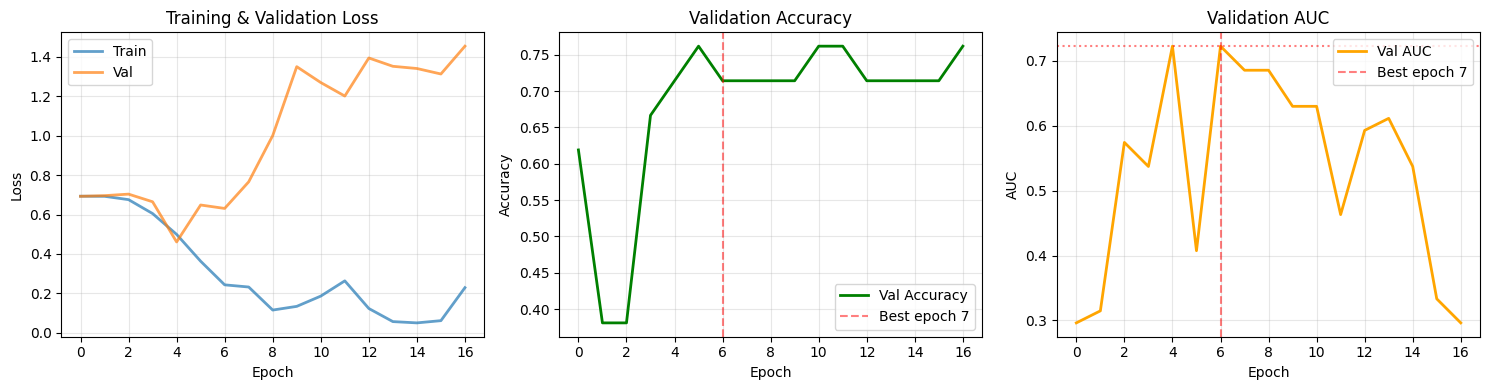

Training curves saved.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train', lw=2, alpha=0.7)
axes[0].plot(history['val_loss'],   label='Val',   lw=2, alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_acc'], label='Val Accuracy', lw=2, color='green')
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch {best_epoch+1}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history['val_auc'], label='Val AUC', lw=2, color='orange')
axes[2].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch {best_epoch+1}')
axes[2].axhline(best_val_auc, color='red', linestyle=':', alpha=0.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].set_title('Validation AUC')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Training curves saved.')

## Step 12: Evaluation on Test Set

In [14]:
# Load best model
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

test_loss, test_acc, test_auc, test_preds, test_labels, test_probs = evaluate(
    model, dataloaders['test'], criterion, DEVICE
)

print('\n' + '='*60)
print('TEST SET RESULTS')
print('='*60)
print(f'Loss     : {test_loss:.4f}')
print(f'Accuracy : {test_acc:.4f}')
print(f'AUC      : {test_auc:.4f}')
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=CLASSES))
print('='*60)


TEST SET RESULTS
Loss     : 0.4765
Accuracy : 0.7619
AUC      : 0.6667

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.84      0.89      0.86        18
   PNEUMONIA       0.00      0.00      0.00         3

    accuracy                           0.76        21
   macro avg       0.42      0.44      0.43        21
weighted avg       0.72      0.76      0.74        21



## Step 13: Confusion Matrix

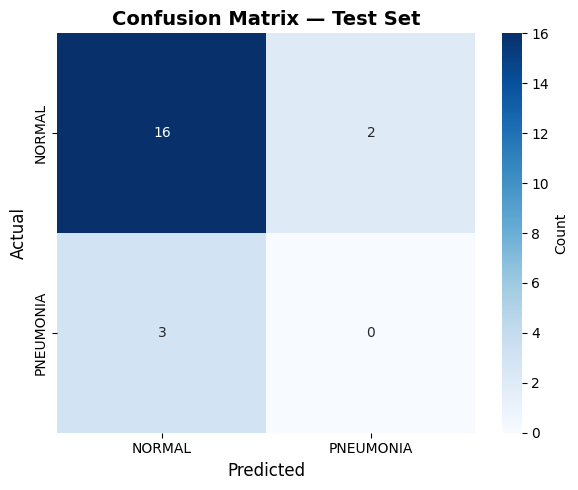

In [15]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

## Step 14: ROC Curve

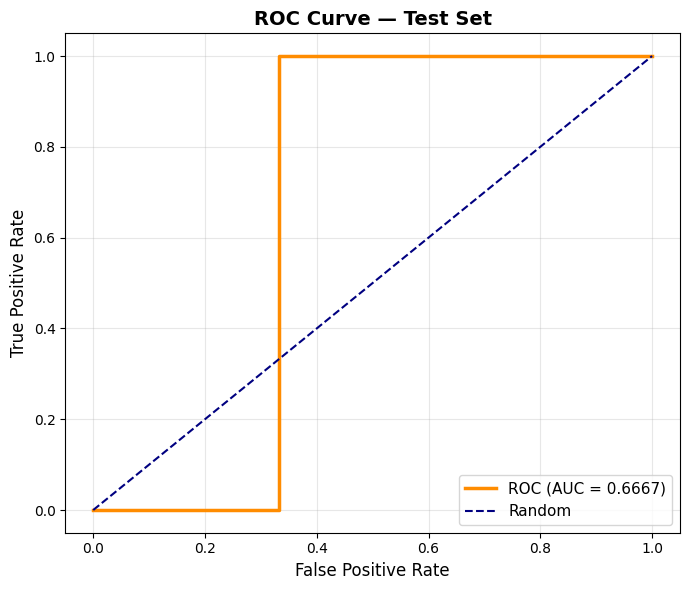

Test AUC: 0.6667


In [16]:
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Test Set', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'roc_curve.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Test AUC: {roc_auc:.4f}')

## Step 15: Save Image Features for Phase 2 — Split-Wise (No Leakage)

In [17]:
print('\nExtracting and saving image features for Phase 2 (split-wise)...')
model.eval()

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    split_loader = DataLoader(
        MIMICDataset(split_df, tfms['val']),  # val transform: no augmentation
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    feats = []
    labs  = []

    with torch.no_grad():
        for imgs, labels in split_loader:
            feat = model.get_features(imgs.to(DEVICE)).cpu()
            feats.append(feat)
            labs.extend(labels.tolist())

    img_features = torch.cat(feats)  # [N, 1024]

    feat_path = os.path.join(SAVE_DIR, f'image_features_{split_name}.pt')
    torch.save({'features': img_features, 'labels': torch.tensor(labs)}, feat_path)
    print(f'{split_name:6s} | Features shape: {img_features.shape} | Saved to {feat_path}')

    meta_df          = split_df[['subject_id', 'study_id', 'label', 'label_name']].copy()
    meta_df['split'] = split_name
    meta_path        = feat_path.replace('.pt', '_meta.csv')
    meta_df.to_csv(meta_path, index=False)

print('\nPhase 1 COMPLETE.')
print('Features ready for Phase 2 (multimodal fusion with BERT text features).')
print(f'\nOutputs saved to: {SAVE_DIR}')
for f in os.listdir(SAVE_DIR):
    print(f'  - {f}')


Extracting and saving image features for Phase 2 (split-wise)...
train  | Features shape: torch.Size([97, 1024]) | Saved to C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\outputs\image_features_train.pt
val    | Features shape: torch.Size([21, 1024]) | Saved to C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\outputs\image_features_val.pt
test   | Features shape: torch.Size([21, 1024]) | Saved to C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\outputs\image_features_test.pt

Phase 1 COMPLETE.
Features ready for Phase 2 (multimodal fusion with BERT text features).

Outputs saved to: C:\2026\PneumoFusionNet\mimic\mimic_pilot_139\outputs
  - best_pneumofusion_mimic.pth
  - confusion_matrix.png
  - image_features_test.pt
  - image_features_test_meta.csv
  - image_features_train.pt
  - image_features_train_meta.csv
  - image_features_val.pt
  - image_features_val_meta.csv
  - roc_curve.png
  - sample_images.png
  - training_history.png


## Summary & Next Steps

### Key Pipeline Features
1. **Stratified train/val/test split (70/15/15)** to prevent data leakage and evaluate generalizability.
2. **Validation AUC checkpointing** to save the checkpoint that generalizes best on unseen data.
3. **WeightedRandomSampler** to handle class imbalance in CrossEntropyLoss.
4. **Dataset-specific normalization stats** dynamically computed from training images.
5. **Gradient clipping and Learning Rate Warmup** to stabilize training.
6. **Split-wise feature extraction** for downstream Phase 2 multimodal fusion.

### Phase 2 Next Steps
- Load BERT-encoded radiology reports
- Fuse image features (1024-d) with text embeddings (768-d)
- Train end-to-end multimodal classifier
- Compare Phase 1 vs Phase 2 performance